# MountainCar Discretization

This notebook builds a finite abstract MDP for `MountainCar-v0`.


In [1]:
%load_ext autoreload
%autoreload 2

import math
import numpy as np
import random
import torch
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

# This starts from the current working directory
# and goes up until it finds the 'fogas_torch' folder or '.git'
def find_root(current_path, marker="fogas_torch"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
print(f"Project root found at: {PROJECT_ROOT}")

# Add project root to sys.path so we can import local packages
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from fogas_torch import LinearMDP, PolicySolver, EnvDataCollector
from fogas_torch.algorithm import (
    FOGASSolverVectorized,
    FOGASOracleSolverVectorized,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)
from fogas_torch.dataset_collection.dataset_analyzer import DatasetAnalyzer
from fogas_torch.fqi.fqi_solver import FQISolver
from fogas_torch.fqi.fqi_evaluator import FQIEvaluator

seed = 44
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Project root found at: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code
Using device: cpu


## Discretization design

MountainCar observations are `(position, velocity)`.

State grid:
- `position`: 36 bins on `[-1.2, 0.6]`
- `velocity`: 28 bins on `[-0.07, 0.07]`

This gives `36 * 28 = 1008` non-terminal abstract states.

Action space:
- `0`: push left
- `1`: no push
- `2`: push right

The environment already has an exact **discrete** action space, so unlike the continuous version there is no action discretization step.

We add one absorbing abstract state:
- `GOAL_STATE_ID`: successful termination (`position >= 0.5` and `velocity >= goal_velocity`)

Total abstract states: `1009`.

As with the continuous notebook, we do not infer `P` and `r` from data. Gymnasium already gives the exact transition and reward equations, so we build the abstract model directly from them.

We also do **not** add a separate time-limit state. The `200`-step truncation is a wrapper-level constraint that depends on elapsed time, not only on the observation, so it is recorded in the offline dataset but excluded from the Markov abstraction itself.


In [17]:
ENV_ID = "MountainCar-v0"
GAMMA = 0.99
GOAL_POSITION = 0.5
GOAL_VELOCITY = 0.0
MIN_POSITION = -1.2
MAX_POSITION = 0.6
MAX_SPEED = 0.07
FORCE = 0.001
GRAVITY_COEFF = 0.0025
TIME_LIMIT = 200

STATE_BINS = np.array([40, 80], dtype=np.int64)
OBS_LOW = np.array([MIN_POSITION, -MAX_SPEED], dtype=np.float64)
OBS_HIGH = np.array([MAX_POSITION, MAX_SPEED], dtype=np.float64)
ACTION_IDS = np.array([0, 1, 2], dtype=np.int64)
ACTION_LABELS = {0: "left", 1: "coast", 2: "right"}
ACTION_ACCELERATIONS = np.array([-1, 0, 1], dtype=np.int64)
ACTION_FORCES = ACTION_ACCELERATIONS.astype(np.float64) * FORCE
N_ACTIONS = int(len(ACTION_IDS))

CORE_STATE_COUNT = int(np.prod(STATE_BINS))
GOAL_STATE_ID = CORE_STATE_COUNT
N_STATES = CORE_STATE_COUNT + 1

states = torch.arange(N_STATES, dtype=torch.int64)
actions = torch.arange(N_ACTIONS, dtype=torch.int64)

BIN_EDGES = [
    np.linspace(lo, hi, n_bins + 1, dtype=np.float64)
    for lo, hi, n_bins in zip(OBS_LOW, OBS_HIGH, STATE_BINS)
]
BIN_CENTERS = [0.5 * (edges[:-1] + edges[1:]) for edges in BIN_EDGES]


def clip_obs(obs):
    obs = np.asarray(obs, dtype=np.float64)
    return np.clip(obs, OBS_LOW, OBS_HIGH)


def is_goal_obs(obs, goal_velocity=GOAL_VELOCITY):
    position, velocity = np.asarray(obs, dtype=np.float64)
    return bool(position >= GOAL_POSITION and velocity >= goal_velocity)


def obs_to_multi_bin(obs):
    obs = clip_obs(obs)
    multi = []
    for value, lo, hi, n_bins in zip(obs, OBS_LOW, OBS_HIGH, STATE_BINS):
        width = (hi - lo) / n_bins
        idx = int(np.floor((value - lo) / width))
        idx = min(max(idx, 0), int(n_bins) - 1)
        multi.append(idx)
    return tuple(multi)


def multi_bin_to_state_id(multi_bin):
    return int(np.ravel_multi_index(multi_bin, STATE_BINS))


def state_id_to_multi_bin(state_id):
    return tuple(np.unravel_index(int(state_id), STATE_BINS))


def obs_to_state_id(obs):
    return multi_bin_to_state_id(obs_to_multi_bin(obs))


def state_id_to_center_obs(state_id):
    state_id = int(state_id)
    if state_id == GOAL_STATE_ID:
        return np.array([np.nan, np.nan], dtype=np.float64)
    multi_bin = state_id_to_multi_bin(state_id)
    return np.array([BIN_CENTERS[d][idx] for d, idx in enumerate(multi_bin)], dtype=np.float64)


def action_id_to_label(action_id):
    return ACTION_LABELS[int(action_id)]


def action_id_to_force(action_id):
    return float(ACTION_FORCES[int(action_id)])


INITIAL_OBS_REFERENCE = np.array([-0.5, 0.0], dtype=np.float64)
INITIAL_STATE_ID = obs_to_state_id(INITIAL_OBS_REFERENCE)

env = gym.make(ENV_ID, goal_velocity=GOAL_VELOCITY)
sampled_initial_obs, _ = env.reset(seed=seed)
env.close()

print(f"Sampled initial observation: {sampled_initial_obs}")
print(f"Reference initial observation: {INITIAL_OBS_REFERENCE}")
print(f"Reference initial abstract state id: {INITIAL_STATE_ID}")
print(f"Non-terminal abstract states: {CORE_STATE_COUNT}")
print(f"Total abstract states: {N_STATES}")
print(f"Discrete action ids: {ACTION_IDS}")
print(f"Action labels: {[ACTION_LABELS[int(a)] for a in ACTION_IDS]}")


Sampled initial observation: [-0.5754869  0.       ]
Reference initial observation: [-0.5  0. ]
Reference initial abstract state id: 1240
Non-terminal abstract states: 3200
Total abstract states: 3201
Discrete action ids: [0 1 2]
Action labels: ['left', 'coast', 'right']


## Exact MountainCar dynamics

We use the exact Gymnasium dynamics and reward function instead of estimating them from data.

Official references:
- Docs: https://gymnasium.farama.org/main/environments/classic_control/mountain_car/
- Source: https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/classic_control/mountain_car.py

For default `goal_velocity = 0.0`, Gymnasium uses:
- `velocity_{t+1} = clip(velocity_t + (action - 1) * 0.001 - 0.0025 * cos(3 * position_t), -0.07, 0.07)`
- `position_{t+1} = clip(position_t + velocity_{t+1}, -1.2, 0.6)`
- left-wall collisions reset negative velocity to `0.0`
- reward is always `-1.0` on non-absorbing transitions


In [18]:
def mountaincar_step(obs, action_id, goal_velocity=GOAL_VELOCITY):
    position, velocity = np.asarray(obs, dtype=np.float64)
    action_id = int(action_id)
    if action_id not in (0, 1, 2):
        raise ValueError(f"MountainCar action must be 0, 1, or 2. Got {action_id}.")

    velocity = velocity + (action_id - 1) * FORCE - GRAVITY_COEFF * math.cos(3.0 * position)
    velocity = float(np.clip(velocity, -MAX_SPEED, MAX_SPEED))

    position = position + velocity
    position = float(np.clip(position, MIN_POSITION, MAX_POSITION))

    if position == MIN_POSITION and velocity < 0.0:
        velocity = 0.0

    terminated = bool(position >= GOAL_POSITION and velocity >= goal_velocity)
    reward = -1.0

    next_obs = np.array([position, velocity], dtype=np.float64)
    return next_obs, float(reward), terminated


example_next_obs, example_reward, example_done = mountaincar_step(INITIAL_OBS_REFERENCE, 2)
print(f"Example initial observation: {INITIAL_OBS_REFERENCE}")
print(f"Example next observation: {example_next_obs}")
print(f"Example reward: {example_reward:.4f}")
print(f"Example terminated: {example_done}")


Example initial observation: [-0.5  0. ]
Example next observation: [-0.49917684  0.00082316]
Example reward: -1.0000
Example terminated: False


In [19]:
# Initialize matrices
# P[s, a, s'] represents the probability of transitioning to state s' given state s and action a
P = np.zeros((N_STATES, N_ACTIONS, N_STATES), dtype=np.float64)
# r[s, a] represents the expected reward for taking action a in state s
r = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)

for s in range(N_STATES):
    for a in ACTION_IDS:
        # Handle the absorbing Goal State
        if s == GOAL_STATE_ID:
            # If we are already at the goal, we stay there forever with zero reward
            P[s, a, s] = 1.0
            r[s, a] = 0.0
            continue
            
        # 1. Get the representative continuous observation for state s
        obs = state_id_to_center_obs(s)
        
        # 2. Simulate the environment dynamics
        next_obs, reward, terminated = mountaincar_step(obs, a)
        
        # 3. Determine the resulting discrete state
        if terminated:
            next_s = GOAL_STATE_ID
        else:
            next_s = obs_to_state_id(next_obs)
            
        # 4. Update the matrices (Transitions are deterministic in this discretization)
        P[s, a, next_s] = 1.0
        r[s, a] = reward

print(f"Transition matrix P shape: {P.shape}")
print(f"Reward matrix r shape: {r.shape}")

# Quick sanity check: Every state-action pair should have transition probabilities summing to 1.0
assert np.allclose(P.sum(axis=2), 1.0), "Transition probabilities don't sum to 1!"

Transition matrix P shape: (3201, 3, 3201)
Reward matrix r shape: (3201, 3)


In [ ]:
# Tabular one-hot features over state-action pairs
D = N_STATES * N_ACTIONS

def phi(state_id, action_id):
    feat = torch.zeros(D, dtype=torch.float64)
    idx = int(state_id) * N_ACTIONS + int(action_id)
    feat[idx] = 1.0
    return feat

# Since phi is one-hot, omega is just the flattened reward table
omega = torch.from_numpy(r.reshape(-1)).to(dtype=torch.float64)

# PolicySolver expects P with shape (N_STATES * N_ACTIONS, N_STATES)
P_flat = torch.from_numpy(P.reshape(N_STATES * N_ACTIONS, N_STATES)).to(dtype=torch.float64)

mdp = PolicySolver(
    states=states,
    actions=actions,
    phi=phi,
    omega=omega,
    gamma=GAMMA,
    x0=INITIAL_STATE_ID,
    P=P_flat,
    terminal_states={GOAL_STATE_ID},
)

print("MDP built.")
print("Phi dimension:", mdp.d)
print("Optimal return:", mdp.optimal_policy_return())

pi_star = mdp.pi_star.reshape(N_STATES, N_ACTIONS)
greedy_actions = torch.argmax(pi_star, dim=1)

print("Initial state greedy action:", action_id_to_label(greedy_actions[INITIAL_STATE_ID].item()))


MDP built.
Phi dimension: 9603
Optimal return: -0.6851908268190479
Initial state greedy action: left
Goal state policy: tensor([1., 0., 0.], dtype=torch.float64)


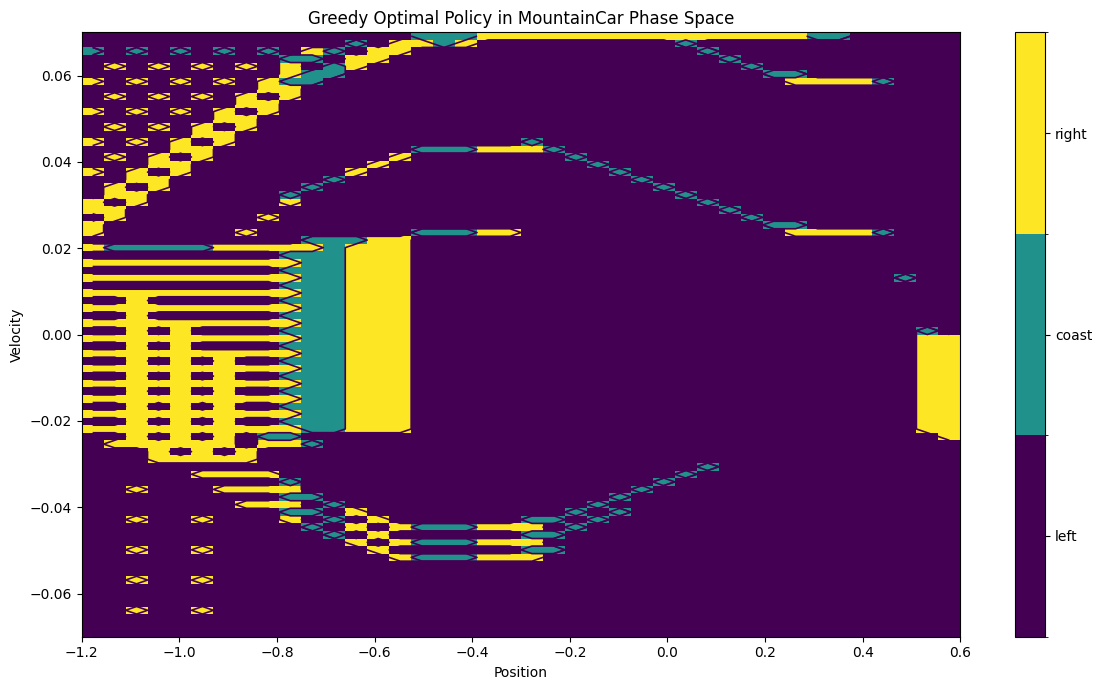

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Greedy optimal action for each abstract state
pi_star = mdp.pi_star.reshape(N_STATES, N_ACTIONS)
greedy_actions = torch.argmax(pi_star, dim=1).cpu().numpy()

policy_grid = np.full(tuple(STATE_BINS), fill_value=-1, dtype=np.int64)
for s in range(CORE_STATE_COUNT):
    i, j = state_id_to_multi_bin(s)
    policy_grid[i, j] = greedy_actions[s]

# Grid in physical coordinates
X, V = np.meshgrid(BIN_CENTERS[0], BIN_CENTERS[1], indexing="ij")

# Colormap: left / coast / right
cmap = ListedColormap(["#440154", "#21918c", "#fde725"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, ax = plt.subplots(figsize=(12, 7))

pcm = ax.pcolormesh(
    BIN_EDGES[0],
    BIN_EDGES[1],
    policy_grid.T,
    cmap=cmap,
    norm=norm,
    shading="flat",
)

# Optional: draw boundaries between action regions
for a in [0, 1]:
    ax.contour(
        X,
        V,
        (policy_grid == a).astype(float),
        levels=[0.5],
        linewidths=1.2,
    )

ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_title("Greedy Optimal Policy in MountainCar Phase Space")

cbar = fig.colorbar(pcm, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["left", "coast", "right"])

plt.tight_layout()
plt.show()